In [1]:

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import openeo

Conectarse al API usando los datos de usuario y contraseña

In [3]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=JYOV-RDNL 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


In [4]:
#Areas de interes
lago_atitlan = {
    "west": -91.326256,
    "east": -91.07151,
    "south": 14.5948,
    "north": 14.750979
}
lago_amatitlan = {
    "west": -90.638065,
    "east": -90.512924, 
    "south": 14.412347,
    "north": 14.493799
}


## Ejercicio 2: Obtención de Datos Raster

Usando `openEO` para descargar B03, B04, B05 y B08 de la colección `SENTINEL2_L2A` para las fechas especificadas.

In [5]:
import os
import datetime
from datetime import date

os.makedirs("data", exist_ok=True)

fechas_atitlan = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17",
    "2025-11-21", "2025-12-29", "2026-02-12", "2026-03-24",
    "2026-04-13", "2026-04-28", "2026-07-22"
]

fechas_amatitlan = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24",
    "2026-01-08", "2026-02-02", "2026-02-07", "2026-03-29",
    "2026-04-13", "2026-04-28", "2026-06-19"
]

lagos = {
    "atitlan": {"bbox": lago_atitlan, "fechas": fechas_atitlan},
    "amatitlan": {"bbox": lago_amatitlan, "fechas": fechas_amatitlan},
}

def descargar_bandas(lago, bbox, fecha):
    """Descarga B03, B04, B05, B08 para un lago y una fecha, si no existe ya localmente."""
    out_path = f"data/{lago}_{fecha}.tif"
    if os.path.exists(out_path):
        return out_path

    d0 = date.fromisoformat(fecha)
    d1 = d0 + datetime.timedelta(days=1)  # ventana de 1 dia para que openeo encuentre la escena

    cube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=[str(d0), str(d1)],
        bands=["B03", "B04", "B05", "B08"],
    )
    cube = cube.reduce_dimension(dimension="t", reducer="mean")
    cube.download(out_path)
    return out_path


In [6]:
# Descarga para ambos lagos (puede tardar varios minutos)
for lago, info in lagos.items():
    for fecha in info["fechas"]:
        try:
            path = descargar_bandas(lago, info["bbox"], fecha)
            print(f"OK: {path}")
        except Exception as e:
            print(f"FALLO {lago} {fecha}: {e}")


OK: data/atitlan_2025-01-18.tif
OK: data/atitlan_2025-04-13.tif
OK: data/atitlan_2025-05-13.tif
OK: data/atitlan_2025-07-17.tif
OK: data/atitlan_2025-11-21.tif
OK: data/atitlan_2025-12-29.tif
OK: data/atitlan_2026-02-12.tif
OK: data/atitlan_2026-03-24.tif
OK: data/atitlan_2026-04-13.tif
OK: data/atitlan_2026-04-28.tif
OK: data/atitlan_2026-07-22.tif
OK: data/amatitlan_2025-01-28.tif
OK: data/amatitlan_2025-04-15.tif
OK: data/amatitlan_2025-04-28.tif
OK: data/amatitlan_2025-11-24.tif
OK: data/amatitlan_2026-01-08.tif
OK: data/amatitlan_2026-02-02.tif
OK: data/amatitlan_2026-02-07.tif
OK: data/amatitlan_2026-03-29.tif
OK: data/amatitlan_2026-04-13.tif
OK: data/amatitlan_2026-04-28.tif
OK: data/amatitlan_2026-06-19.tif


In [53]:
def calcular_indices(tif_path, ndwi_umbral=0.0, offset=1000):
    with rasterio.open(tif_path) as src:
        b03 = src.read(1).astype("float32") + offset
        b04 = src.read(2).astype("float32") + offset
        b05 = src.read(3).astype("float32") + offset
        b08 = src.read(4).astype("float32") + offset

    eps = 1e-6

    def safe_div(num, den):
        out = np.where(den != 0, num / (den + eps), np.nan)
        return out.astype("float32")

    ndvi = safe_div(b08 - b04, b08 + b04)
    ndwi = safe_div(b03 - b08, b03 + b08)
    ndci = safe_div(b05 - b04, b05 + b04)

    ndvi = np.clip(ndvi, -1, 1)
    ndwi = np.clip(ndwi, -1, 1)
    ndci = np.clip(ndci, -1, 1)

    chl = 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071
    chl = np.clip(chl, 0, None)

    mascara_agua = ndwi > ndwi_umbral

    return {
        "ndvi": ndvi, "ndwi": ndwi, "ndci": ndci, "chl": chl,
        "mascara_agua": mascara_agua
    }

In [54]:
# OTRA CELDA NUEVA: aplica la función a todas las imágenes descargadas
import pandas as pd

registros = []

for lago, info in lagos.items():
    for fecha in info["fechas"]:
        tif_path = f"data/{lago}_{fecha}.tif"
        if not os.path.exists(tif_path):
            continue
        idx = calcular_indices(tif_path)
        m = idx["mascara_agua"]
        if m.sum() == 0:
            m = np.ones_like(m, dtype=bool)

        registros.append({
            "lago": lago,
            "fecha": pd.to_datetime(fecha),
            "cyano_prom": float(np.nanmean(idx["chl"][m])),
            "ndvi_prom": float(np.nanmean(idx["ndvi"][m])),
            "ndwi_prom": float(np.nanmean(idx["ndwi"][m])),
            "pct_pixeles_agua": float(m.sum() / m.size * 100),
        })

df_indices = pd.DataFrame(registros).sort_values(["lago", "fecha"]).reset_index(drop=True)
df_indices

,lago,fecha,cyano_prom,ndvi_prom,ndwi_prom,pct_pixeles_agua
0,amatitlan,2025-01-28,4.445820,-0.023582,0.061476,12.664860
1,amatitlan,2025-04-15,4.529418,-0.022311,0.085745,12.262653
2,amatitlan,2025-04-28,4.692558,-0.013462,0.090145,11.925797
3,amatitlan,2025-11-24,4.373219,-0.028400,0.055391,12.377157
4,amatitlan,2026-01-08,4.559324,-0.007439,0.051243,11.470749
5,amatitlan,2026-02-02,4.333424,-0.006523,0.025238,11.207582
6,amatitlan,2026-02-07,4.340629,-0.016867,0.043368,12.379803
7,amatitlan,2026-03-29,4.853209,-0.015561,0.090652,12.556210
8,amatitlan,2026-04-13,5.082404,-0.008041,0.102814,12.722112
9,amatitlan,2026-04-28,5.063820,-0.007485,0.120464,10.963179


## Ejercicio #4

In [61]:
# Ejercicio 4.1: índice promedio de cianobacteria por lago y por fecha
tabla_promedios = df_indices[["lago", "fecha", "cyano_prom"]].sort_values(["lago", "fecha"])
tabla_promedios

,lago,fecha,cyano_prom
0,amatitlan,2025-01-28,4.445820
1,amatitlan,2025-04-15,4.529418
2,amatitlan,2025-04-28,4.692558
3,amatitlan,2025-11-24,4.373219
4,amatitlan,2026-01-08,4.559324
5,amatitlan,2026-02-02,4.333424
6,amatitlan,2026-02-07,4.340629
7,amatitlan,2026-03-29,4.853209
8,amatitlan,2026-04-13,5.082404
9,amatitlan,2026-04-28,5.063820


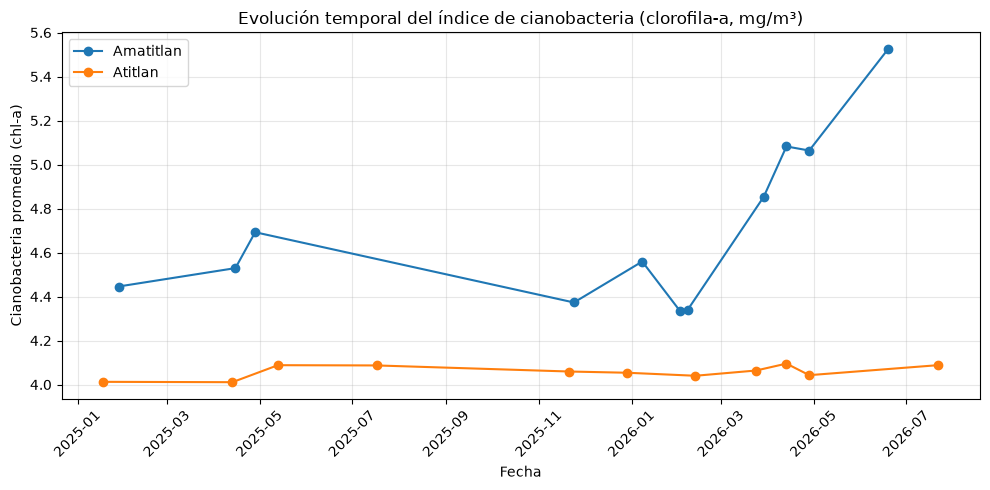

In [62]:
# Ejercicio 4.2: evolución temporal (gráfico de línea por lago)
fig, ax = plt.subplots(figsize=(10, 5))

for lago, grupo in df_indices.groupby("lago"):
    ax.plot(grupo["fecha"], grupo["cyano_prom"], marker="o", label=lago.capitalize())

ax.set_title("Evolución temporal del índice de cianobacteria (clorofila-a, mg/m³)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cianobacteria promedio (chl-a)")
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("evolucion_temporal_cianobacteria.png", dpi=150)
plt.show()

In [63]:
# Ejercicio 4.3: identificación de picos de floración y fechas críticas
picos = {}
fechas_criticas = {}

for lago, grupo in df_indices.groupby("lago"):
    grupo = grupo.sort_values("fecha")

    idx_max = grupo["cyano_prom"].idxmax()
    picos[lago] = grupo.loc[idx_max]

    umbral = grupo["cyano_prom"].quantile(0.75)
    criticas = grupo[grupo["cyano_prom"] >= umbral]
    fechas_criticas[lago] = criticas[["fecha", "cyano_prom"]]

    print(f"\n{lago.capitalize()}: pico máximo el {picos[lago]['fecha'].date()} con chl-a={picos[lago]['cyano_prom']:.4f}")
    print(f"Fechas críticas (>= percentil 75, umbral={umbral:.4f}):")
    print(criticas[["fecha", "cyano_prom"]].to_string(index=False))

picos_df = pd.DataFrame(picos).T


Amatitlan: pico máximo el 2026-06-19 con chl-a=5.5254
Fechas críticas (>= percentil 75, umbral=4.9585):
     fecha  cyano_prom
2026-04-13    5.082404
2026-04-28    5.063820
2026-06-19    5.525364

Atitlan: pico máximo el 2026-04-13 con chl-a=4.0954
Fechas críticas (>= percentil 75, umbral=4.0876):
     fecha  cyano_prom
2025-05-13    4.088183
2026-04-13    4.095394
2026-07-22    4.088386


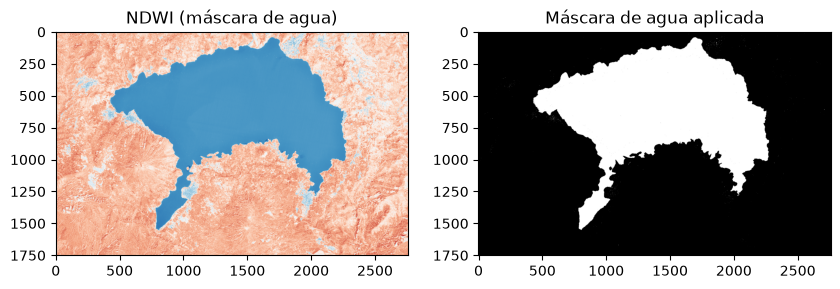

In [64]:
import matplotlib.pyplot as plt

idx = calcular_indices("data/atitlan_2025-01-18.tif")
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(idx["ndwi"], cmap="RdBu")
axs[0].set_title("NDWI (máscara de agua)")
axs[1].imshow(idx["mascara_agua"], cmap="gray")
axs[1].set_title("Máscara de agua aplicada")
plt.show()

NDVI  -> media: 0.0006162936  mediana: 0.0024764736
chl-a -> media: 4.012524  mediana: 4.0214467


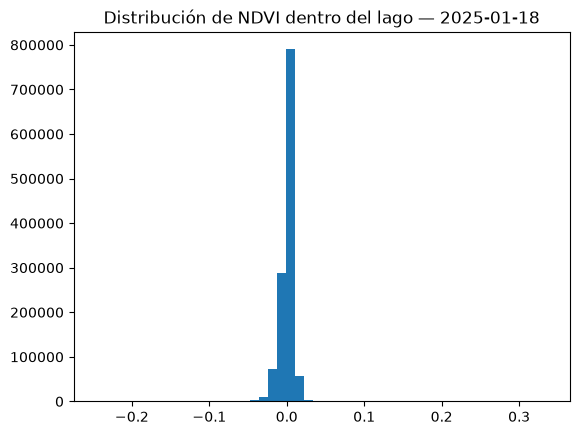

In [65]:
ndvi_agua = idx["ndvi"][idx["mascara_agua"]]
chl_agua = idx["chl"][idx["mascara_agua"]]

print("NDVI  -> media:", np.nanmean(ndvi_agua), " mediana:", np.nanmedian(ndvi_agua))
print("chl-a -> media:", np.nanmean(chl_agua), " mediana:", np.nanmedian(chl_agua))

plt.hist(ndvi_agua, bins=50)
plt.title("Distribución de NDVI dentro del lago — 2025-01-18")
plt.show()